In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score, roc_curve
)
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv(r'C:\Users\yashw\OneDrive\Desktop\creditcard.csv')

print(df.shape)
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True) * 100)

(284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


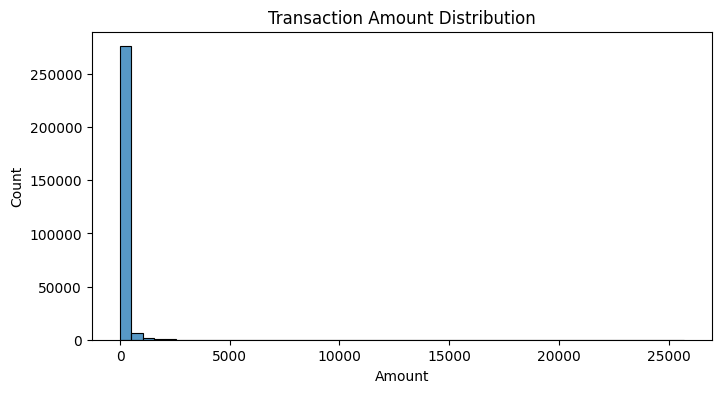

In [3]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Amount'], bins=50)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.show()

In [4]:
df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

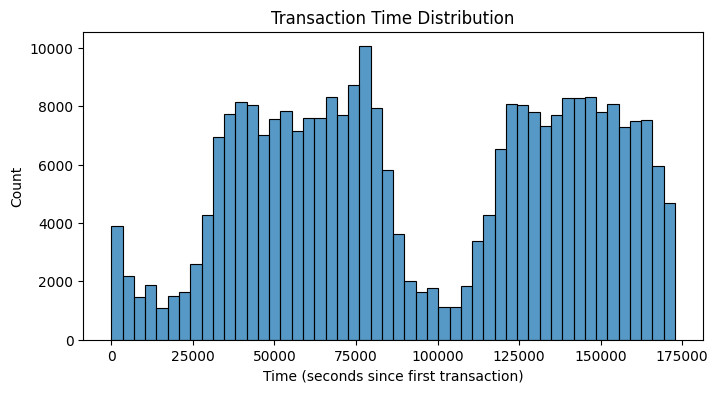

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df['Time'], bins=50)
plt.title('Transaction Time Distribution')
plt.xlabel('Time (seconds since first transaction)')
plt.show()

In [6]:
df["Time"].describe()

count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64

In [7]:
print("Nulls:\n", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

Nulls:
 0
Duplicates: 1081


In [8]:
df.drop_duplicates(inplace=True)

In [9]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


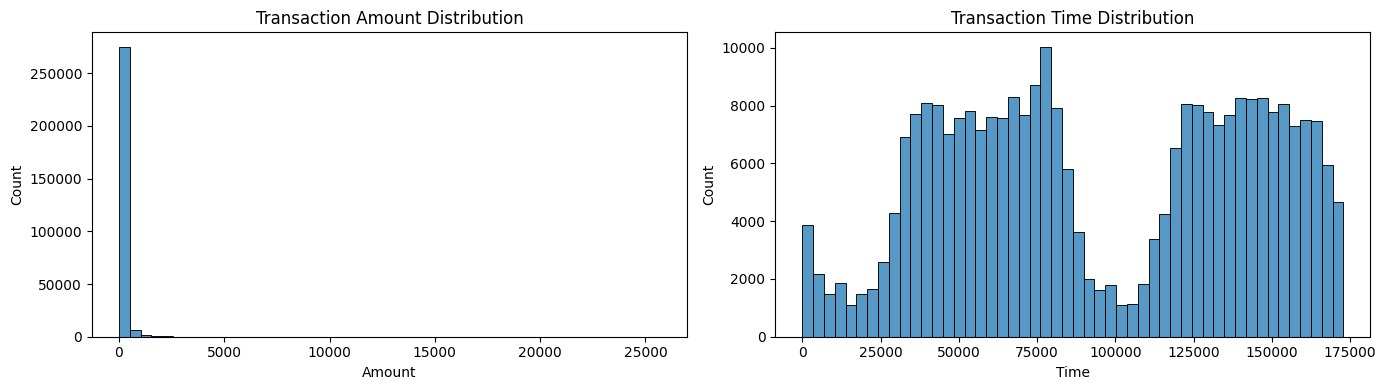

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['Amount'], bins=50, ax=ax[0])
ax[0].set_title('Transaction Amount Distribution')
sns.histplot(df['Time'], bins=50, ax=ax[1])
ax[1].set_title('Transaction Time Distribution')
plt.tight_layout()
plt.show()

In [11]:
corr = df.corr()['Class'].sort_values(ascending=False)
print("Top correlations with Class:\n", corr.head(10))
print("Bottom correlations with Class:\n", corr.tail(10))

Top correlations with Class:
 Class    1.000000
V11      0.149067
V4       0.129326
V2       0.084624
V19      0.033631
V8       0.033068
V21      0.026357
V27      0.021892
V20      0.021486
V28      0.009682
Name: Class, dtype: float64
Bottom correlations with Class:
 V9    -0.094021
V1    -0.094486
V18   -0.105340
V7    -0.172347
V3    -0.182322
V16   -0.187186
V10   -0.206971
V12   -0.250711
V14   -0.293375
V17   -0.313498
Name: Class, dtype: float64


In [12]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [13]:
scaler = RobustScaler()
X_train[['Amount', 'Time']] = scaler.fit_transform(X_train[['Amount', 'Time']])
X_test[['Amount', 'Time']] = scaler.transform(X_test[['Amount', 'Time']])

In [14]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", y_train_res.value_counts().to_dict())

Before SMOTE: {0: 226602, 1: 378}
After SMOTE: {0: 226602, 1: 226602}


In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1)
}
results = {}

In [16]:
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    report = classification_report(y_test, y_pred, output_dict=True)
    roc_auc = roc_auc_score(y_test, y_proba)

    results[name] = {
        'precision': report['1']['precision'],
        'recall': report['1']['recall'],
        'f1': report['1']['f1-score'],
        'roc_auc': roc_auc,
    }

    print(f"\n{name}\n")
    print(classification_report(y_test, y_pred))
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(f"ROC-AUC: {roc_auc:.4f}")


Logistic Regression

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746

Confusion matrix:
 [[55188  1463]
 [   12    83]]
ROC-AUC: 0.9600

Decision Tree

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.39      0.69      0.50        95

    accuracy                           1.00     56746
   macro avg       0.69      0.85      0.75     56746
weighted avg       1.00      1.00      1.00     56746

Confusion matrix:
 [[56547   104]
 [   29    66]]
ROC-AUC: 0.8465

Random Forest

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.91      0.78      0.84        

In [17]:
results_df = pd.DataFrame(results).T
results_df = results_df
print("\nModel comparison\n")
print(results_df)


Model comparison

                     precision    recall        f1   roc_auc
Logistic Regression   0.053687  0.873684  0.101158  0.960046
Decision Tree         0.388235  0.694737  0.498113  0.846451
Random Forest         0.913580  0.778947  0.840909  0.959037
XGBoost               0.752475  0.800000  0.775510  0.965207
